# Práctica: regresión lineal, mínimos cuadrados y modelo AR

**Curso:** MA2008B · Análisis Numérico para la Optimización No Lineal  
**Tema:** Optimización de mínimos cuadrados aplicada a regresión lineal y modelos autorregresivos  
**Objetivo:** implementar mínimos cuadrados como problema de optimización y extender la misma idea a un modelo AR($p$), donde los regresores son rezagos de la propia serie temporal.

---

## Instrucciones generales

En este notebook encontrarán celdas marcadas con `TODO`. El objetivo es que completen esas partes, ejecuten los experimentos y contesten las preguntas finales.


## 1. Contexto del problema

Una empresa quiere modelar sus ventas semanales usando como variable explicativa el gasto en publicidad.

- $x_i$: gasto en publicidad de la semana $i$.
- $y_i$: ventas observadas de la semana $i$.

Supondremos un modelo lineal:

$$
\hat y_i = \theta_0 + \theta_1 x_i
$$

En forma matricial:

$$
\hat y = X\theta
$$

con

$$
X = \begin{bmatrix}
1 & x_1 \\
1 & x_2 \\
\vdots & \vdots \\
1 & x_n
\end{bmatrix},
\qquad
\theta = \begin{bmatrix}
\theta_0 \\
\theta_1
\end{bmatrix}.
$$

El problema de mínimos cuadrados consiste en encontrar $\theta$ que minimice:

$$
J(\theta) = \frac{1}{2n}\|X\theta - y\|_2^2.
$$

El factor $\frac{1}{2n}$ se usa por conveniencia matemática: el $2$ cancela al derivar, y $n$ normaliza por el número de observaciones.

In [ ]:
# Importar librerías
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Para reproducibilidad
np.random.seed(42)

## 2. Generación de datos sintéticos

Vamos a crear datos simulados para que conozcamos el comportamiento esperado del modelo.

El proceso real será:

$$
y = 12 + 3.2x + \varepsilon,
$$

donde $\varepsilon$ representa ruido aleatorio.

En un problema real no conoceríamos los valores verdaderos $12$ y $3.2$; el objetivo sería estimarlos a partir de los datos.

In [ ]:
# Número de observaciones
n = 80

# Variable explicativa: gasto en publicidad
x = np.linspace(0, 20, n)

# Parámetros verdaderos, desconocidos para el modelo
theta0_real = 12.0
theta1_real = 3.2

# Ruido aleatorio
ruido = np.random.normal(loc=0.0, scale=6.0, size=n)

# Variable respuesta: ventas
y = theta0_real + theta1_real * x + ruido

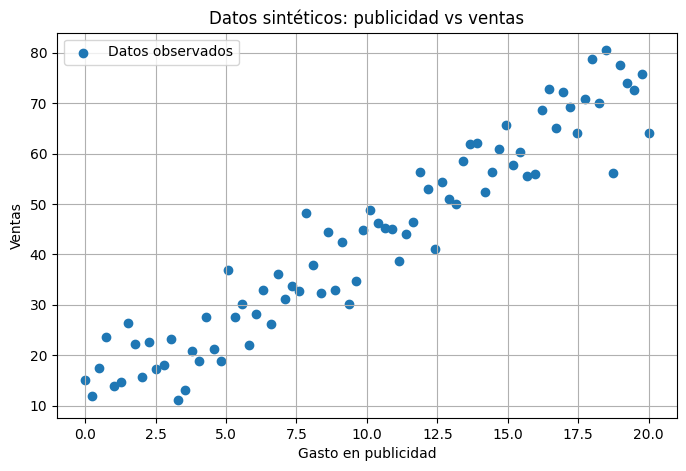

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(x, y, label="Datos observados")
plt.xlabel("Gasto en publicidad")
plt.ylabel("Ventas")
plt.title("Datos sintéticos: publicidad vs ventas")
plt.legend()
plt.grid(True)
plt.show()

## 3. Construcción de la matriz de diseño

Para incluir el intercepto $\theta_0$, agregamos una columna de unos a la matriz $X$.

$$
X = \begin{bmatrix}
1 & x_1 \\
1 & x_2 \\
\vdots & \vdots \\
1 & x_n
\end{bmatrix}
$$

La primera columna permite estimar el intercepto; la segunda columna contiene la variable explicativa.

In [ ]:
# Construcción de la matriz de diseño
X = np.column_stack([np.ones(n), x])

print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)
print("Primeras 5 filas de X:")
print(X[:5])

Dimensión de X: (80, 2)
Dimensión de y: (80,)
Primeras 5 filas de X:
[[1.         0.        ]
 [1.         0.25316456]
 [1.         0.50632911]
 [1.         0.75949367]
 [1.         1.01265823]]


## 4. Ejercicio 1: función de predicción

Completen la función `predict`. Debe recibir la matriz de diseño `X` y el vector de parámetros `theta`, y debe devolver:

$$
\hat y = X\theta
$$

In [8]:
def predict(X, theta):
    """
    Calcula las predicciones de un modelo lineal.

    Parámetros
    ----------
    X : ndarray de dimensión (n, p)
        Matriz de diseño.
    theta : ndarray de dimensión (p,)
        Vector de parámetros.

    Retorna
    -------
    y_hat : ndarray de dimensión (n,)
        Predicciones del modelo.
    """
    return X @ theta
    # TODO: implementar y_hat = X @ theta

In [9]:
# Verificación rápida de predict
X_test = np.array([[1, 3], [1, 4], [1, 5]])
theta_test = np.array([2, 10])

# Resultado esperado: [32, 42, 52]
assert np.allclose(predict(X_test, theta_test), np.array([32, 42, 52]))
print("Prueba superada: predict funciona correctamente.")

Prueba superada: predict funciona correctamente.


## 5. Ejercicio 2: función de costo de mínimos cuadrados

La función objetivo será:

$$
J(\theta) = \frac{1}{2n}\sum_{i=1}^n (\hat y_i - y_i)^2
$$

En forma vectorial:

$$
J(\theta) = \frac{1}{2n}(X\theta - y)^\top(X\theta - y)
$$

Completen la función `cost_function`.

In [10]:
def cost_function(X, y, theta):
    """
    Calcula la función de costo de mínimos cuadrados.
    J(theta) = (1 / (2n)) * ||X theta - y||^2
    """
    n = len(y)
    # TODO:
    # 1. Calcular y_hat usando predict(X, theta)
    y_hat = predict(X, theta)
    # 2. Calcular el vector de errores: y_hat - y
    error = y_hat - y
    # 3. Calcular J(theta)
    J = (1 / (2 * n)) * (error.T @ error)
    return J

In [11]:
# Verificación rápida de cost_function
X_test = np.array([[1, 1], [1, 2]])
y_test = np.array([3, 5])
theta_test = np.array([1, 2])  # Predice exactamente [3, 5]

assert np.isclose(cost_function(X_test, y_test, theta_test), 0.0)
print("Prueba superada: cost_function funciona correctamente para ajuste perfecto.")

Prueba superada: cost_function funciona correctamente para ajuste perfecto.


## 6. Ejercicio 3: gradiente de la función de costo

La función de costo es:

$$
J(\theta) = \frac{1}{2n}\|X\theta - y\|_2^2.
$$

Su gradiente con respecto a $\theta$ es:

$$
\nabla J(\theta) = \frac{1}{n}X^\top(X\theta - y).
$$

Completen la función `gradient`.

In [12]:
def gradient(X, y, theta):
    """
    Calcula el gradiente de la función de costo.
    grad = (1 / n) * X.T @ (X @ theta - y)
    """
    n = len(y)
    # TODO: implementar la fórmula vectorizada del gradiente
    y_hat = predict(X, theta)
    error = y_hat - y
    grad = (1 / n) * (X.T @ error)
    return grad

In [13]:
# Verificación rápida del gradiente usando un caso simple
X_test = np.array([[1, 1], [1, 2]])
y_test = np.array([3, 5])
theta_test = np.array([1, 2])  # Ajuste perfecto, gradiente debe ser cero

assert np.allclose(gradient(X_test, y_test, theta_test), np.array([0.0, 0.0]))
print("Prueba superada: gradient devuelve cero cuando el ajuste es perfecto.")

Prueba superada: gradient devuelve cero cuando el ajuste es perfecto.


## 7. Ejercicio 4: descenso por gradiente

El método de descenso por gradiente actualiza los parámetros mediante:

$$
\theta^{(k+1)} = \theta^{(k)} - \alpha \nabla J(\theta^{(k)}),
$$

donde:

- $\alpha$ es la tasa de aprendizaje.
- $k$ es el número de iteración.
- $\nabla J(\theta^{(k)})$ es el gradiente evaluado en los parámetros actuales.

Completen la función `gradient_descent`.

In [14]:
def gradient_descent(X, y, theta_init, alpha=0.001, num_iter=5000):
    """
    Optimiza theta usando descenso por gradiente.
    Parámetros
    ----------
    X : ndarray
        Matriz de diseño.
    y : ndarray
        Vector de observaciones.
    theta_init : ndarray
        Parámetros iniciales.
    alpha : float
        Tasa de aprendizaje.
    num_iter : int
        Número de iteraciones.
    Retorna
    -------
    theta : ndarray
        Parámetros optimizados.
    cost_history : list
        Valor de la función de costo en cada iteración.
    theta_history : list
        Valores de theta en cada iteración.
    """
    theta = theta_init.astype(float).copy()
    cost_history = []
    theta_history = []
    for k in range(num_iter):
        # TODO:
        # 1. Calcular el costo actual y guardarlo en cost_history
        cost_history.append(cost_function(X, y, theta))
        # 2. Guardar una copia de theta en theta_history
        theta_history.append(theta.copy())
        # 3. Calcular el gradiente
        grad = gradient(X, y, theta)
        # 4. Actualizar theta usando theta = theta - alpha * grad
        theta = theta - alpha * grad
    return theta, cost_history, theta_history

## 8. Ejecutar la optimización

Una vez implementadas las funciones anteriores, ejecuten el descenso por gradiente.

Prueben primero con:

- `theta_init = [0, 0]`
- `alpha = 0.005`
- `num_iter = 10000`

Después experimenten con otros valores de `alpha`.

In [15]:
theta_init = np.array([0.0, 0.0])
alpha = 0.005
num_iter = 10000

theta_gd, cost_history, theta_history = gradient_descent(
    X, y, theta_init, alpha=alpha, num_iter=num_iter
)

print("Parámetros estimados por descenso por gradiente:")
print("theta_0 =", theta_gd[0])
print("theta_1 =", theta_gd[1])
print("Costo final =", cost_history[-1])

Parámetros estimados por descenso por gradiente:
theta_0 = 10.973133113587577
theta_1 = 3.2283817505663506
Costo final = 16.281896283010962


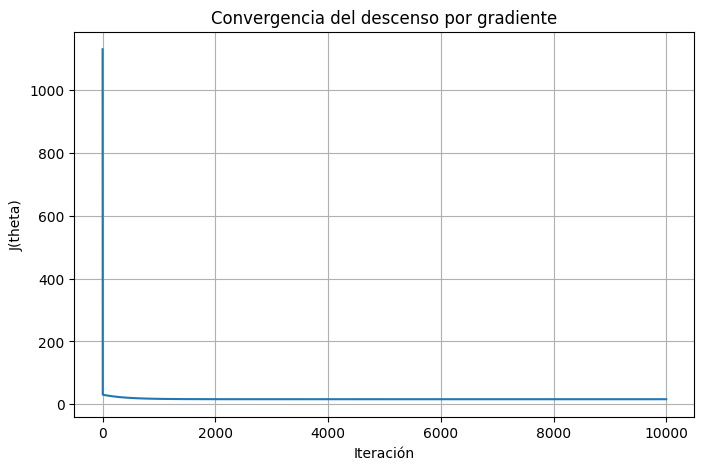

In [16]:
# Gráfica de convergencia del costo
plt.figure(figsize=(8, 5))
plt.plot(cost_history)
plt.xlabel("Iteración")
plt.ylabel("J(theta)")
plt.title("Convergencia del descenso por gradiente")
plt.grid(True)
plt.show()

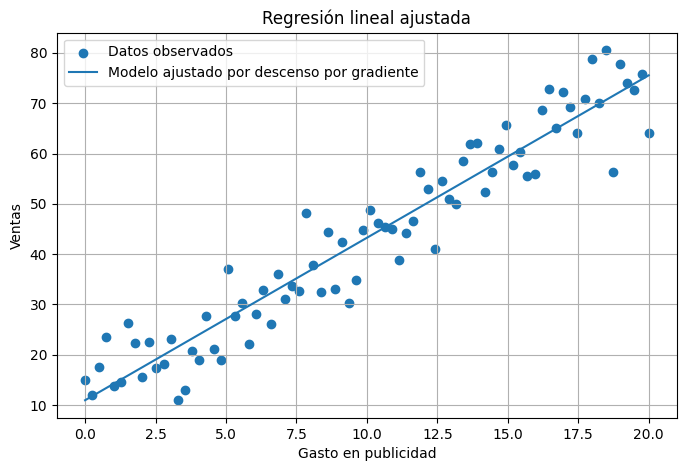

In [17]:
# Visualización del ajuste lineal

y_hat_gd = predict(X, theta_gd)

plt.figure(figsize=(8, 5))
plt.scatter(x, y, label="Datos observados")
plt.plot(x, y_hat_gd, label="Modelo ajustado por descenso por gradiente")
plt.xlabel("Gasto en publicidad")
plt.ylabel("Ventas")
plt.title("Regresión lineal ajustada")
plt.legend()
plt.grid(True)
plt.show()

## 9. Ejercicio 5: solución analítica por ecuaciones normales

Para mínimos cuadrados lineales, también existe una solución cerrada:

$$
\hat\theta = (X^\top X)^{-1}X^\top y.
$$

Completen la función `normal_equation`.

**Nota numérica:** en problemas reales, `np.linalg.solve` suele ser preferible a calcular explícitamente la inversa. Aquí usaremos la fórmula para conectar directamente con la teoría.

In [18]:
def normal_equation(X, y):
    """
    Calcula la solución analítica de mínimos cuadrados.
    theta_hat = (X.T @ X)^(-1) @ X.T @ y
    """
    # TODO: implementar la ecuación normal
    theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y
    return theta_hat

In [19]:
theta_ne = normal_equation(X, y)

print("Parámetros estimados por ecuaciones normales:")
print("theta_0 =", theta_ne[0])
print("theta_1 =", theta_ne[1])

print("Comparación:")
print("theta por GD:", theta_gd)
print("theta por ecuación normal:", theta_ne)
print("Diferencia:", theta_gd - theta_ne)

Parámetros estimados por ecuaciones normales:
theta_0 = 10.97316655504463
theta_1 = 3.228379253517273
Comparación:
theta por GD: [10.97313311  3.22838175]
theta por ecuación normal: [10.97316656  3.22837925]
Diferencia: [-3.34414571e-05  2.49704908e-06]


## 10. Visualización de la superficie de costo

La función de costo de una regresión lineal con dos parámetros tiene forma convexa. En este caso, podemos visualizarla como curvas de nivel en el plano $(\theta_0, \theta_1)$.

Ejecuten esta sección después de haber implementado y corrido el descenso por gradiente.

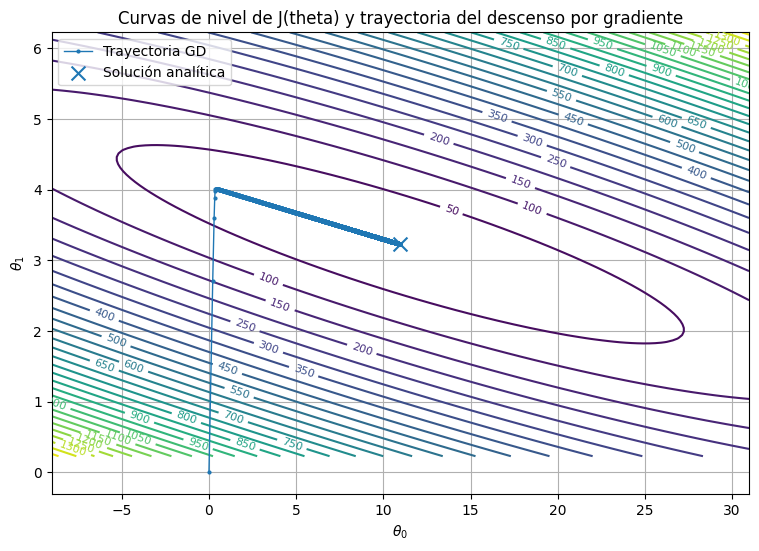

In [20]:
# Crear una malla de valores para theta_0 y theta_1
theta0_vals = np.linspace(theta_ne[0] - 20, theta_ne[0] + 20, 120)
theta1_vals = np.linspace(theta_ne[1] - 3, theta_ne[1] + 3, 120)

J_vals = np.zeros((len(theta1_vals), len(theta0_vals)))

for i, t1 in enumerate(theta1_vals):
    for j, t0 in enumerate(theta0_vals):
        theta_tmp = np.array([t0, t1])
        J_vals[i, j] = cost_function(X, y, theta_tmp)

# Convertir historial a arreglo
TH = np.array(theta_history)

plt.figure(figsize=(9, 6))
contours = plt.contour(theta0_vals, theta1_vals, J_vals, levels=30)
plt.clabel(contours, inline=True, fontsize=8)
plt.plot(TH[:, 0], TH[:, 1], marker="o", markersize=2, linewidth=1, label="Trayectoria GD")
plt.scatter(theta_ne[0], theta_ne[1], marker="x", s=100, label="Solución analítica")
plt.xlabel(r"$\theta_0$")
plt.ylabel(r"$\theta_1$")
plt.title("Curvas de nivel de J(theta) y trayectoria del descenso por gradiente")
plt.legend()
plt.grid(True)
plt.show()

## 11. Experimentos

Respondan las siguientes preguntas modificando los hiperparámetros y observando las gráficas.

### Experimento A: tasa de aprendizaje

Prueben al menos cuatro valores de `alpha`, por ejemplo:

- `0.0001`
- `0.001`
- `0.005`
- `0.05`

Preguntas:

1. ¿Qué ocurre si `alpha` es demasiado pequeña?
2. ¿Qué ocurre si `alpha` es demasiado grande?
3. ¿Cuál valor parece converger mejor para estos datos?

### Experimento B: punto inicial

Prueben distintos valores iniciales:

- `[0, 0]`
- `[100, -10]`
- `[-50, 10]`

Preguntas:

1. ¿El algoritmo converge al mismo punto?
2. ¿Cambia la cantidad de iteraciones necesarias?
3. ¿Por qué la convexidad de la función de costo es importante aquí?

In [21]:
# Espacio para experimentos

alphas = [0.0001, 0.001, 0.005, 0.05]

for a in alphas:
    try:
        theta_tmp, cost_tmp, _ = gradient_descent(X, y, theta_init, alpha=a, num_iter=3000)
        print(f"alpha = {a:>7} | theta = {theta_tmp} | costo final = {cost_tmp[-1]:.4f}")
    except Exception as e:
        print(f"alpha = {a:>7} | error: {e}")

alpha =  0.0001 | theta = [1.08155956 3.96697829] | costo final = 28.7439
alpha =   0.001 | theta = [5.98204063 3.60106297] | costo final = 19.4562
alpha =   0.005 | theta = [10.7348936   3.24617092] | costo final = 16.2891
alpha =    0.05 | theta = [nan nan] | costo final = nan


/tmp/ipykernel_32652/869097943.py:13: RuntimeWarning: overflow encountered in matmul
  J = (1 / (2 * n)) * (error.T @ error)
/tmp/ipykernel_32652/514785657.py:10: RuntimeWarning: overflow encountered in matmul
  grad = (1 / n) * (X.T @ error)
/tmp/ipykernel_32652/2965086461.py:17: RuntimeWarning: invalid value encountered in matmul
  return X @ theta


## 12. Extensión opcional: regresión lineal múltiple

Ahora supongan que las ventas dependen de dos variables:

- $x_1$: gasto en publicidad.
- $x_2$: descuento promedio aplicado.

El modelo sería:

$$
\hat y = \theta_0 + \theta_1 x_1 + \theta_2 x_2.
$$

En forma matricial:

$$
\hat y = X\theta,
$$

pero ahora $X$ tiene tres columnas: una columna de unos, una columna para publicidad y una columna para descuento.

Adapten el código anterior para resolver este caso.

In [ ]:
# Extensión opcional: regresión lineal múltiple
np.random.seed(7)

n2 = 100
x1 = np.linspace(0, 20, n2)                         # publicidad
x2 = np.random.uniform(0, 15, size=n2)               # descuento promedio
ruido2 = np.random.normal(0, 5, size=n2)

y2 = 10 + 2.8 * x1 + 1.5 * x2 + ruido2

# TODO:
# 1. Construir X2 con columnas [1, x1, x2]
# 2. Definir theta_init2 con tres parámetros
# 3. Optimizar usando gradient_descent
# 4. Comparar con normal_equation


## 13. Práctica adicional: modelo AR por mínimos cuadrados

En la primera parte del notebook estimamos una regresión lineal del tipo:

$$
\hat y = X\theta.
$$

Ahora aplicaremos exactamente la misma idea a una serie temporal. La diferencia es que, en un modelo autorregresivo, los regresores no son variables externas, sino valores pasados de la propia serie.

Un modelo AR($p$) se escribe como:

$$
y_t = a_1 y_{t-1} + a_2 y_{t-2} + \cdots + a_p y_{t-p} + e_t.
$$

En forma matricial:

$$
Y = \Phi \theta + e,
$$

donde:

$$
\theta = \begin{bmatrix} a_1 & a_2 & \cdots & a_p \end{bmatrix}^\top
$$

y cada fila de $\Phi$ contiene los rezagos de la serie.

**Meta de esta práctica:** estimar los parámetros de un modelo AR($p$) usando mínimos cuadrados y comparar la solución por descenso por gradiente contra la solución analítica.



### 13.1 Generación de una serie temporal AR(2)

Primero simularemos una serie generada por el modelo:

$$
y_t = 0.65 y_{t-1} - 0.25 y_{t-2} + e_t,
$$

con $e_t$ como ruido aleatorio de media cero.

En un problema real no conoceríamos los coeficientes $0.65$ y $-0.25$. Aquí los conocemos únicamente para verificar si el método de estimación funciona.


In [22]:

# Generación de una serie temporal AR(2)
np.random.seed(42)

T = 160
coeficientes_reales = np.array([0.65, -0.25])
sigma_ruido = 0.8

ruido = np.random.normal(loc=0.0, scale=sigma_ruido, size=T)
y_ar = np.zeros(T)

# Condiciones iniciales
y_ar[0] = ruido[0]
y_ar[1] = ruido[1]

# Simulación del proceso AR(2)
for t in range(2, T):
    y_ar[t] = (
        coeficientes_reales[0] * y_ar[t - 1]
        + coeficientes_reales[1] * y_ar[t - 2]
        + ruido[t]
    )

print("Coeficientes reales:", coeficientes_reales)
print("Primeros 10 valores de la serie:")
print(y_ar[:10])


Coeficientes reales: [ 0.65 -0.25]
Primeros 10 valores de la serie:
[ 0.39737132 -0.11061144  0.34691056  1.47156861  0.68246926 -0.1115967
  1.02021508  1.30498676  0.21760812  0.24924662]


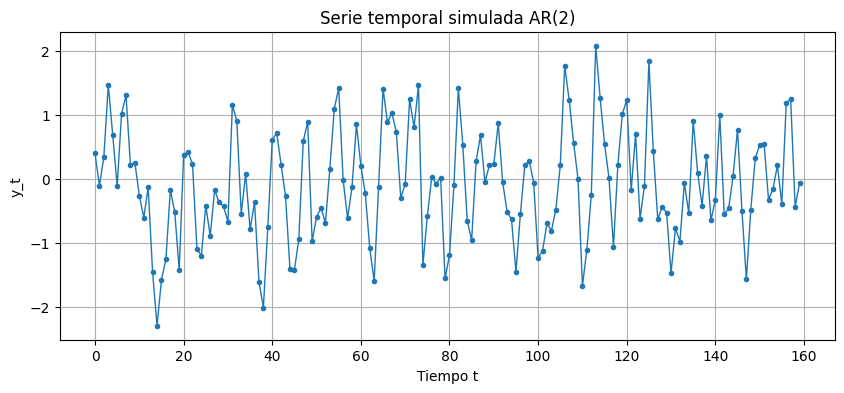

In [23]:

# Visualización de la serie temporal simulada
plt.figure(figsize=(10, 4))
plt.plot(y_ar, marker="o", markersize=3, linewidth=1)
plt.xlabel("Tiempo t")
plt.ylabel("y_t")
plt.title("Serie temporal simulada AR(2)")
plt.grid(True)
plt.show()



### 13.2 Ejercicio 6: construir la matriz de rezagos

Para estimar un modelo AR($p$), necesitamos construir:

$$
Y = \begin{bmatrix}
y_p \\
y_{p+1} \\
\vdots \\
y_{T-1}
\end{bmatrix},
\quad
\Phi = \begin{bmatrix}
y_{p-1} & y_{p-2} & \cdots & y_0 \\
y_p & y_{p-1} & \cdots & y_1 \\
\vdots & \vdots & \ddots & \vdots \\
y_{T-2} & y_{T-3} & \cdots & y_{T-p-1}
\end{bmatrix}.
$$

Para cada tiempo $t$, la fila correspondiente de $\Phi$ debe contener:

$$
\begin{bmatrix}
y_{t-1} & y_{t-2} & \cdots & y_{t-p}
\end{bmatrix}.
$$


In [24]:

def build_ar_design(y, p):
    """
    Construye la matriz de diseño para un modelo AR(p).

    Parámetros
    ----------
    y : np.ndarray
        Serie temporal de longitud T.
    p : int
        Orden del modelo AR.

    Regresa
    -------
    Y : np.ndarray
        Vector objetivo con valores y_t desde t = p hasta T - 1.
    Phi : np.ndarray
        Matriz de regresores con rezagos [y_{t-1}, y_{t-2}, ..., y_{t-p}].

    TODO:
    1. Crear Y usando los valores de y desde la posición p hasta el final.
    2. Crear Phi con T - p filas y p columnas.
    3. En cada fila, colocar los rezagos correspondientes.
    """

    T = len(y)
    # 1. Y contiene y_t para t = p, p+1, ..., T-1
    Y = y[p:]
    # 2. Phi tiene T - p filas y p columnas
    Phi = np.zeros((T - p, p))
    # 3. Llenar cada fila con los rezagos [y_{t-1}, y_{t-2}, ..., y_{t-p}]
    for i, t in enumerate(range(p, T)):
        Phi[i] = [y[t - j] for j in range(1, p + 1)]
    return Y, Phi

In [25]:

# Verificación de la matriz de rezagos
p = 2
Y_ar, Phi_ar = build_ar_design(y_ar, p)

print("Dimensión de Y_ar:", Y_ar.shape)
print("Dimensión de Phi_ar:", Phi_ar.shape)
print("Primeras 5 filas de Phi_ar:")
print(Phi_ar[:5])
print("Primeros 5 valores de Y_ar:")
print(Y_ar[:5])


Dimensión de Y_ar: (158,)
Dimensión de Phi_ar: (158, 2)
Primeras 5 filas de Phi_ar:
[[-0.11061144  0.39737132]
 [ 0.34691056 -0.11061144]
 [ 1.47156861  0.34691056]
 [ 0.68246926  1.47156861]
 [-0.1115967   0.68246926]]
Primeros 5 valores de Y_ar:
[ 0.34691056  1.47156861  0.68246926 -0.1115967   1.02021508]



### 13.3 Ejercicio 7: estimar el modelo AR(2) con descenso por gradiente

Una vez construida la matriz $\Phi$, el modelo AR se convierte en una regresión lineal:

$$
\hat Y = \Phi \theta.
$$

Por lo tanto, podemos reutilizar las funciones ya implementadas:

- `predict`
- `cost_function`
- `gradient`
- `gradient_descent`

El objetivo es minimizar:

$$
J(\theta) = \frac{1}{2N}\|Y - \Phi \theta\|^2.
$$


In [27]:

# Estimación del AR(2) por descenso por gradiente
p = 2
theta_ar_init = np.zeros(p)

# Prueben diferentes valores de alpha si el costo no converge
alpha_ar = 0.01
num_iter_ar = 6000

theta_ar_gd, cost_history_ar, theta_ar_history = gradient_descent(
    Phi_ar,
    Y_ar,
    theta_ar_init,
    alpha=alpha_ar,
    num_iter=num_iter_ar
)

print("Coeficientes reales:       ", coeficientes_reales)
print("Coeficientes estimados GD: ", theta_ar_gd)
print("Costo final:", cost_history_ar[-1])


Coeficientes reales:        [ 0.65 -0.25]
Coeficientes estimados GD:  [ 0.56605702 -0.26533767]
Costo final: 0.2801945760102668


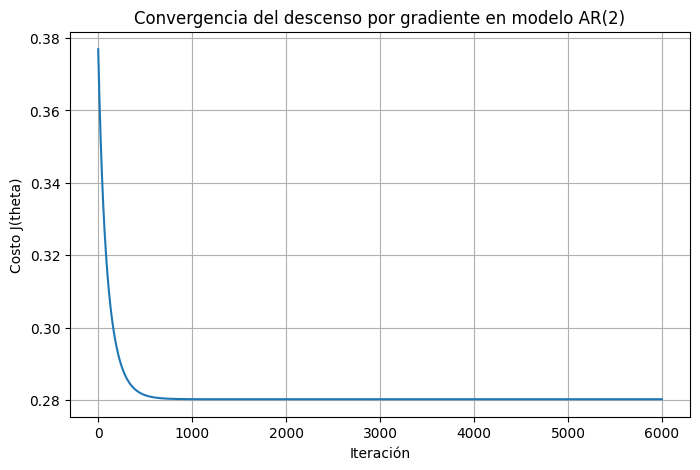

In [28]:

# Gráfica de convergencia para el modelo AR
plt.figure(figsize=(8, 5))
plt.plot(cost_history_ar)
plt.xlabel("Iteración")
plt.ylabel("Costo J(theta)")
plt.title("Convergencia del descenso por gradiente en modelo AR(2)")
plt.grid(True)
plt.show()



### 13.4 Ejercicio 8: comparar contra ecuaciones normales

La solución analítica de mínimos cuadrados también aplica al modelo AR:

$$
\hat\theta = (\Phi^\top \Phi)^{-1}\Phi^\top Y.
$$

Usen la función `normal_equation` implementada antes para comparar los coeficientes estimados.


In [29]:

# Comparación con ecuaciones normales
theta_ar_ne = normal_equation(Phi_ar, Y_ar)

print("Coeficientes reales:                 ", coeficientes_reales)
print("Coeficientes estimados GD:           ", theta_ar_gd)
print("Coeficientes por ecuaciones normales:", theta_ar_ne)

print("Diferencia GD vs normales:", theta_ar_gd - theta_ar_ne)


Coeficientes reales:                  [ 0.65 -0.25]
Coeficientes estimados GD:            [ 0.56605702 -0.26533767]
Coeficientes por ecuaciones normales: [ 0.56605702 -0.26533767]
Diferencia GD vs normales: [-5.40822942e-12  5.40989475e-12]



### 13.5 Ejercicio 9: predicción un paso adelante

Con los coeficientes estimados, podemos calcular la predicción de un paso adelante:

$$
\hat y_t = \hat a_1 y_{t-1} + \hat a_2 y_{t-2} + \cdots + \hat a_p y_{t-p}.
$$

Esta predicción usa los valores observados más recientes como entrada del modelo.


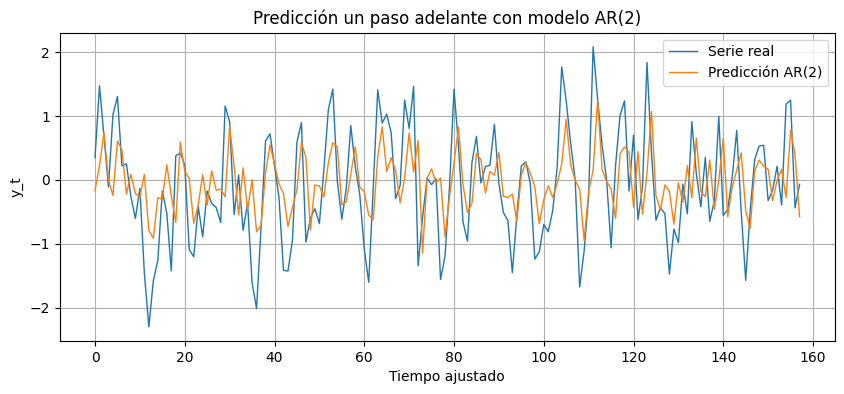

In [30]:

# Predicción dentro de muestra usando los coeficientes estimados
Y_hat_ar = predict(Phi_ar, theta_ar_ne)

plt.figure(figsize=(10, 4))
plt.plot(Y_ar, label="Serie real", linewidth=1)
plt.plot(Y_hat_ar, label="Predicción AR(2)", linewidth=1)
plt.xlabel("Tiempo ajustado")
plt.ylabel("y_t")
plt.title("Predicción un paso adelante con modelo AR(2)")
plt.legend()
plt.grid(True)
plt.show()



### 13.6 Ejercicio 10: separar entrenamiento y prueba

Ahora estimaremos el modelo con una parte de la serie y evaluaremos el error en observaciones no usadas para entrenar.

Esto permite discutir si el modelo realmente generaliza o si solo está ajustando los datos de entrenamiento.


In [31]:

# Separación entrenamiento/prueba sobre la matriz de rezagos ya construida
n_train = 110

Phi_train = Phi_ar[:n_train]
Y_train = Y_ar[:n_train]

Phi_test = Phi_ar[n_train:]
Y_test = Y_ar[n_train:]

# Estimación usando solo entrenamiento
theta_ar_train = normal_equation(Phi_train, Y_train)

Y_train_hat = predict(Phi_train, theta_ar_train)
Y_test_hat = predict(Phi_test, theta_ar_train)

mse_train = np.mean((Y_train - Y_train_hat) ** 2)
mse_test = np.mean((Y_test - Y_test_hat) ** 2)

print("Theta estimado con entrenamiento:", theta_ar_train)
print("MSE entrenamiento:", mse_train)
print("MSE prueba:", mse_test)


Theta estimado con entrenamiento: [ 0.67128778 -0.30186179]
MSE entrenamiento: 0.5391687322293998
MSE prueba: 0.6312831057946405


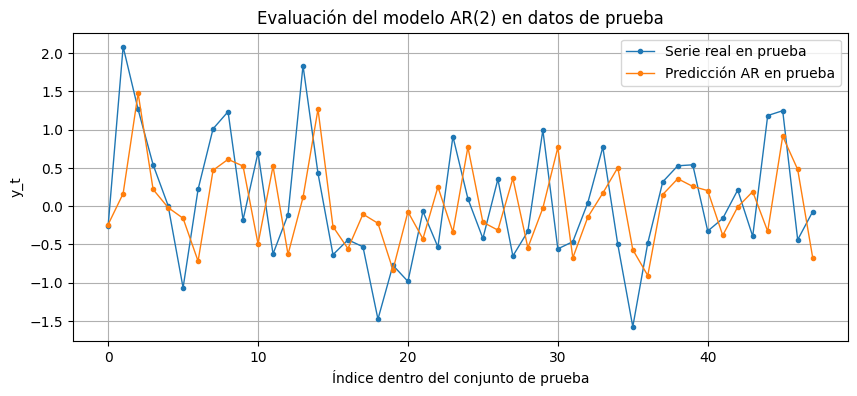

In [32]:

# Visualización de predicciones en el conjunto de prueba
plt.figure(figsize=(10, 4))
plt.plot(Y_test, label="Serie real en prueba", marker="o", markersize=3, linewidth=1)
plt.plot(Y_test_hat, label="Predicción AR en prueba", marker="o", markersize=3, linewidth=1)
plt.xlabel("Índice dentro del conjunto de prueba")
plt.ylabel("y_t")
plt.title("Evaluación del modelo AR(2) en datos de prueba")
plt.legend()
plt.grid(True)
plt.show()



### 13.7 Experimento adicional: cambiar el orden $p$

Repitan la estimación con distintos valores de $p$:

- AR(1)
- AR(2)
- AR(3)
- AR(5)

Comparen el error de entrenamiento y el error de prueba. Un modelo con más rezagos puede ajustar mejor el entrenamiento, pero no necesariamente mejorar la predicción fuera de muestra.


In [ ]:

# Experimento: comparar diferentes órdenes p del modelo AR
ordenes = [1, 2, 3, 5]
resultados_ar = []

for p_exp in ordenes:
    # TODO: construir Y_exp y Phi_exp con build_ar_design
    # TODO: separar entrenamiento y prueba
    # TODO: estimar theta con normal_equation
    # TODO: calcular MSE de entrenamiento y prueba
    # TODO: guardar los resultados en la lista resultados_ar
    pass

# Después de completar el ciclo, pueden convertir resultados_ar en DataFrame:
# resultados_ar_df = pd.DataFrame(resultados_ar)
# resultados_ar_df



## 14. Preguntas finales para entregar

1. Escriban la función objetivo $J(\theta)$ usada en la práctica de regresión lineal.
1.1 $J(\theta) = \frac{1}{2n} \Sigma^{n}_{i = 1} (\hat{y}_i - y_i)²$
2. Expliquen qué representa el gradiente en el contexto de mínimos cuadrados. El gradiente te dice hacia dónde crece más rápido la función de costo, por so nos movemos al sentido opuesto.
3. ¿Por qué el descenso por gradiente necesita una tasa de aprendizaje?
la taza $\alpha$ controla que tan grande es el paso a la dirección.
4. ¿Qué diferencia hay entre la solución por descenso por gradiente y la solución por ecuaciones normales? Las ecuaciónes son densas computacionalmente con matrices grandes, y el descenso de gradiente es iterativo, pero sin inversión de matrices.
5. ¿En qué casos preferirían un método iterativo sobre una solución cerrada? Cuando las matrices son muy grandes, y, por lo tanto, difíciles de invertir. 
6. Interpreten los parámetros estimados $\theta_0$ y $\theta_1$ en el contexto de publicidad y ventas. El intercepto $\theta_0$ es el número de ventas que tienes por default, independeinte de la publicidad; y el coeficiente $\theta_1$ es proporcional al presupuesto de publicidad que inviertas.
7. En el modelo AR($p$), ¿qué representan los coeficientes $a_1, a_2, \ldots, a_p$? Son los coeficientes del resago, entonces miden qué tan relevante es un resago para la medición de hoy.
8. ¿Por qué un modelo AR puede estimarse como una regresión lineal? La neta no sé.
9. Comparen los coeficientes reales del AR(2) con los coeficientes estimados. ¿Qué tan cercanos son?
10. Al probar distintos órdenes $p$, ¿cuál tuvo mejor desempeño en prueba? Justifiquen usando el MSE.
11. ¿Qué diferencia conceptual hay entre una regresión lineal con variable externa y un modelo AR? En la regresión con variable externa predices yy
y usando otra variable distinta (ej. ventas a partir de publicidad). En el AR predices la serie usando su pasado, sin nada de afuera. Uno se apoya en factores externos, el otro en su propia historia.

## Entregable sugerido

Entreguen este notebook ejecutado, con:

- Las funciones completadas.
- Las gráficas de convergencia y ajuste lineal.
- La comparación entre descenso por gradiente y ecuaciones normales.
- La construcción de la matriz de rezagos para el modelo AR.
- La estimación del modelo AR por mínimos cuadrados.
- La comparación de MSE para distintos órdenes $p$.
- Respuestas breves a las preguntas finales.
